In [14]:
import pandas as pd 
import numpy as np
import tensorflow as tf
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, log_loss, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt
import re
import mlflow
from pathlib import Path
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, f1_score, log_loss
import mlflow.tensorflow
import joblib

In [2]:
mlflow.set_tracking_uri("http://127.0.0.1:5001")
experiment = mlflow.set_experiment("pregunta2_ff-boyaca")

print("Tracking URI:", mlflow.get_tracking_uri())
print("Experiment ID:", experiment.experiment_id)

Tracking URI: http://127.0.0.1:5001
Experiment ID: 4


In [3]:
data = pd.read_csv("/Users/joulesss/Documents/DOCTORADO/Materias/AnaliticaComputacional/Proyecto2_Final/data_encoded.csv")

data.head(5)


,periodo,cole_area_ubicacion,cole_bilingue,cole_caracter,cole_cod_mcpio_ubicacion,cole_jornada,cole_mcpio_ubicacion,cole_naturaleza,cole_nombre_establecimiento,estu_genero,...,fami_personashogar,fami_tienecomputador,fami_tieneinternet,fami_tienelavadora,punt_ingles,punt_matematicas,punt_sociales_ciudadanas,punt_c_naturales,punt_lectura_critica,punt_global
0,20162,1,0,2,15238,1,DUITAMA,1,COLEGIO GUILLERMO LEON VALENCIA,1.0,...,NaN,NaN,NaN,NaN,61.0,59.0,63.0,57.0,56.0,295.0
1,20142,0,0,2,15759,1,SOGAMOSO,1,INSTITUCION EDUCATIVA LA INDEPENDENCIA,0.0,...,6.0,1.0,0.0,0.0,52.0,55.0,54.0,60.0,54.0,277.0
2,20152,1,0,1,15835,6,TURMEQUE,1,I.E. TECNICA INDUSTRIAL,0.0,...,3.0,0.0,0.0,1.0,55.0,52.0,50.0,53.0,47.0,254.0
3,20172,1,0,2,15176,1,CHIQUINQUIRA,1,I.E. TECNICA PIO ALBERTO FERRO PEÑA,0.0,...,5.5,0.0,0.0,1.0,59.0,58.0,46.0,51.0,45.0,253.0
4,20172,1,0,2,15759,1,SOGAMOSO,0,COLEGIO COOPERATIVO REYES PATRIA,1.0,...,3.5,1.0,1.0,1.0,75.0,66.0,70.0,65.0,64.0,335.0


## Trtamiento de variables

In [4]:

data['nivel_educacion_padres'] = round((data['fami_educacionmadre']+data['fami_educacionpadre'])/2,0)# tomar el máximo nivel entre ambos padres

data['hacinamiento'] = data['fami_personashogar'] / (data['fami_cuartoshogar'] + 1)


In [5]:
""" def clasificar_ingles(x):
    if 0 <= x <= 36:
        return 0   # Pre A1
    elif 37 <= x <= 57:
        return 1   # A1
    elif 58 <= x <= 70:
        return 2   # A2
    elif 71 <= x <= 100:
        return 3   # B1
    else:
        return None """
        
def clasificar_ingles(x):
    if x <= 58:
        return 0
    else: 
        return 1 
                
 
data["nivel_ingles"] = data["punt_ingles"].apply(clasificar_ingles)

## Variable uso de modelo 

In [6]:

var = [
    "cole_bilingue", "cole_jornada", "cole_area_ubicacion", "cole_naturaleza",
    "cole_caracter", "cole_area_ubicacion",
    "fami_tienecomputador", "fami_tieneinternet", "fami_estratovivienda",
    "nivel_educacion_padres", "hacinamiento", "nivel_ingles"
]


data_p1 = data[var].copy().dropna()

data_p1 = data_p1[~data_p1.isin([-1, "-1"]).any(axis=1)].copy()


cols_to_encode = ["cole_jornada", "cole_caracter"]

encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

encoded_array = encoder.fit_transform(data_p1[cols_to_encode])
encoded_cols = encoder.get_feature_names_out(cols_to_encode)

encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoded_cols,
    index=data_p1.index
).astype(int)


data_p1_f = pd.concat(
    [data_p1.drop(columns=cols_to_encode), encoded_df],
    axis=1
)

data_p1_f

,cole_bilingue,cole_area_ubicacion,cole_naturaleza,cole_area_ubicacion,fami_tienecomputador,fami_tieneinternet,fami_estratovivienda,nivel_educacion_padres,hacinamiento,nivel_ingles,cole_jornada_1,cole_jornada_2,cole_jornada_3,cole_jornada_4,cole_jornada_5,cole_jornada_6,cole_caracter_1,cole_caracter_2,cole_caracter_3,cole_caracter_4
1,0,0,1,0,1.0,0.0,1.0,2.0,2.000000,0,1,0,0,0,0,0,0,1,0,0
2,0,1,1,1,0.0,0.0,1.0,2.0,1.000000,0,0,0,0,0,0,1,1,0,0,0
3,0,1,1,1,0.0,0.0,2.0,4.0,1.375000,1,1,0,0,0,0,0,0,1,0,0
4,0,1,0,1,1.0,1.0,3.0,8.0,1.166667,1,1,0,0,0,0,0,0,1,0,0
5,0,1,0,1,1.0,0.0,2.0,4.0,1.750000,1,0,0,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100042,0,1,1,1,1.0,1.0,2.0,5.0,1.000000,1,1,0,0,0,0,0,0,1,0,0
100043,0,1,1,1,1.0,1.0,1.0,3.0,0.875000,1,0,0,0,0,0,1,0,1,0,0
100044,0,1,1,1,0.0,0.0,1.0,2.0,1.250000,0,0,0,0,0,0,1,1,0,0,0
100046,0,1,1,1,0.0,0.0,1.0,2.0,0.750000,1,1,0,0,0,0,0,0,1,0,0


In [7]:
X = data_p1_f.copy().drop(columns="nivel_ingles")
y = data_p1_f["nivel_ingles"]

## Corelación datos

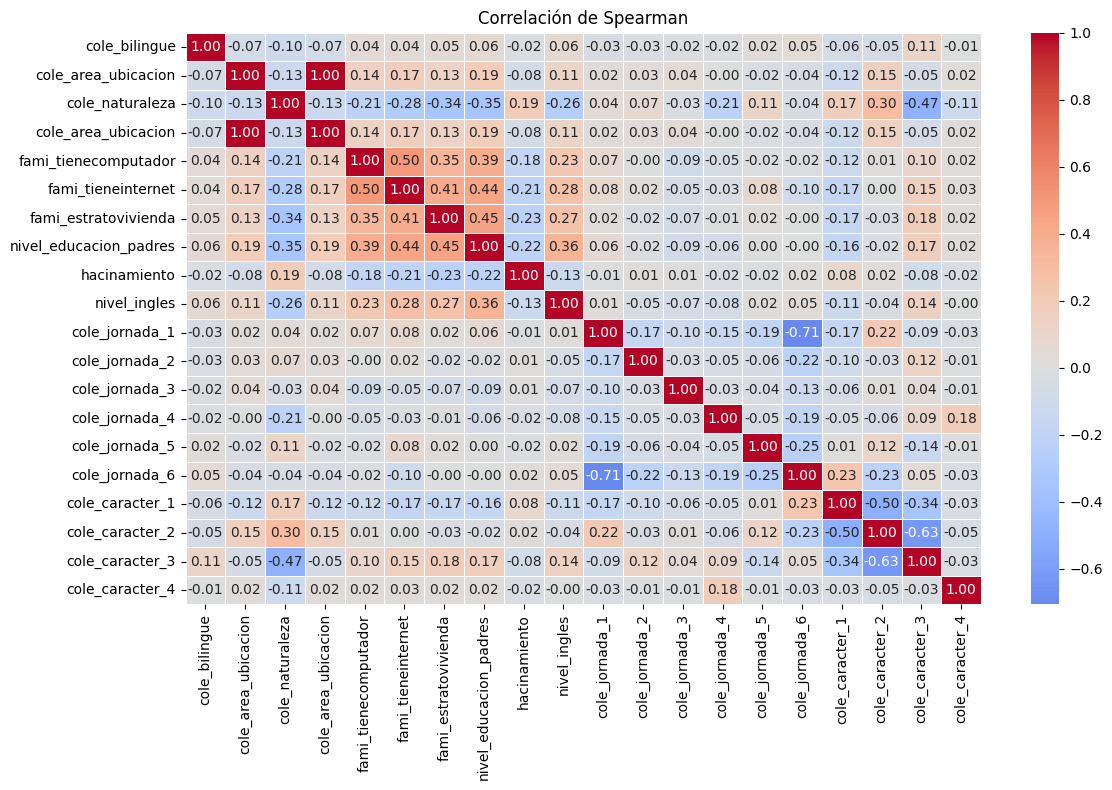

In [8]:
cor = data_p1_f.corr(method = "spearman")

plt.figure(figsize=(12, 8))
sns.heatmap(
    cor,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlación de Spearman")
plt.tight_layout()
plt.show()


### Partición de datos

In [9]:
# 70% Train - 30% temp -> redirigido a test y validacion 
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    shuffle = True,
    stratify=y
)

# 1% Validacion - 15% test 
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    shuffle = True,
    stratify=y_temp
)

In [10]:
data["nivel_ingles"].value_counts(normalize=True).sort_index()

nivel_ingles
0    0.77515
1    0.22485
Name: proportion, dtype: float64

## Creación de red

In [11]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

X_dev = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_dev = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

X_dev = X_dev.astype("float32")
X_test = X_test.astype("float32")
y_dev = y_dev.astype("int32")
y_test = y_test.astype("int32")

num_classes = len(np.unique(y_dev))
input_dim = X_dev.shape[1]
class_labels = sorted(np.unique(y_dev).tolist())
class_names = [f"class_{label}" for label in class_labels]


def build_model(input_dim, num_classes, hidden_layers=(16, 16), dropout_rate=0.2, learning_rate=1e-3):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(input_dim,)))

    for units in hidden_layers:
        model.add(tf.keras.layers.Dense(units, activation="relu"))
        model.add(tf.keras.layers.Dropout(dropout_rate))

    model.add(tf.keras.layers.Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def safe_name(x):
    return re.sub(r"[^0-9a-zA-Z_]+", "_", str(x))


class MLflowDatasetMetricsLogger(tf.keras.callbacks.Callback):
    def __init__(self, set_name, X_ref, y_ref, class_labels=None, class_names=None):
        super().__init__()
        self.set_name = set_name
        self.X_ref = X_ref
        self.y_ref = np.array(y_ref)
        self.class_labels = class_labels or sorted(np.unique(self.y_ref).tolist())
        if class_names is None:
            self.class_names = {label: f"class_{label}" for label in self.class_labels}
        else:
            self.class_names = {
                label: safe_name(name) for label, name in zip(self.class_labels, class_names)
            }

    def on_epoch_end(self, epoch, logs=None):
        y_prob = self.model.predict(self.X_ref, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)

        mlflow.log_metric(
            f"{self.set_name}_cross_entropy",
            float(log_loss(self.y_ref, y_prob, labels=self.class_labels)),
            step=epoch,
        )
        mlflow.log_metric(
            f"{self.set_name}_accuracy",
            float(accuracy_score(self.y_ref, y_pred)),
            step=epoch,
        )
        mlflow.log_metric(
            f"{self.set_name}_f1_macro",
            float(f1_score(self.y_ref, y_pred, average="macro")),
            step=epoch,
        )

        report = classification_report(
            self.y_ref,
            y_pred,
            labels=self.class_labels,
            output_dict=True,
            zero_division=0,
        )

        for label in self.class_labels:
            class_name = self.class_names[label]
            mlflow.log_metric(
                f"{self.set_name}_{class_name}_f1",
                float(report[str(label)]["f1-score"]),
                step=epoch,
            )


### Entrenamiento del modelo

In [13]:
param_grid = {
    "hidden_layers": [(16, 8, 16),(8,12,24)],
    "dropout_rate": [0.2],
    "learning_rate": [1e-3],
    "batch_size": [64],
    "epochs": [10]
}

skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=SEED)
results = []

for params in ParameterGrid(param_grid):
    fold_losses = []
    fold_f1s = []

    run_name = (
        f"train_"
        f"bs_{params['batch_size']}_"
        f"dr_{params['dropout_rate']}_"
        f"lr_{params['learning_rate']}_"
        f"hl_{'-'.join(map(str, params['hidden_layers']))}"
    )

    with mlflow.start_run(experiment_id=experiment.experiment_id, run_name=run_name):
        mlflow.log_params({
            "batch_size": params["batch_size"],
            "dropout_rate": params["dropout_rate"],
            "epochs": params["epochs"],
            "hidden_layers": str(params["hidden_layers"]),
            "learning_rate": params["learning_rate"],
            "n_splits": skf.n_splits,
            "sampling_method": "SMOTE"
        })

        for fold, (train_idx, val_idx) in enumerate(skf.split(X_dev, y_dev), start=1):
            with mlflow.start_run(run_name=f"{run_name}_fold_{fold}", nested=True):
                X_tr = X_dev.iloc[train_idx].copy()
                X_va = X_dev.iloc[val_idx].copy()
                y_tr = y_dev.iloc[train_idx].copy()
                y_va = y_dev.iloc[val_idx].copy()

                scaler = StandardScaler()
                X_tr_scaled = scaler.fit_transform(X_tr)
                X_va_scaled = scaler.transform(X_va)

                smote = SMOTE(random_state=SEED)
                X_tr_bal, y_tr_bal = smote.fit_resample(X_tr_scaled, y_tr)

                model = build_model(
                    input_dim=input_dim,
                    num_classes=num_classes,
                    hidden_layers=params["hidden_layers"],
                    dropout_rate=params["dropout_rate"],
                    learning_rate=params["learning_rate"]
                )

                early_stop = tf.keras.callbacks.EarlyStopping(
                    monitor="val_loss",
                    patience=8,
                    restore_best_weights=True
                )

                train_logger = MLflowDatasetMetricsLogger(
                    set_name="train",
                    X_ref=X_tr_bal,
                    y_ref=y_tr_bal,
                    class_labels=class_labels,
                    class_names=class_names,
                )
                val_logger = MLflowDatasetMetricsLogger(
                    set_name="val",
                    X_ref=X_va_scaled,
                    y_ref=y_va,
                    class_labels=class_labels,
                    class_names=class_names,
                )

                history = model.fit(
                    X_tr_bal, y_tr_bal,
                    validation_data=(X_va_scaled, y_va),
                    epochs=params["epochs"],
                    batch_size=params["batch_size"],
                    verbose=1,
                    callbacks=[train_logger, val_logger, early_stop]
                )

                y_prob = model.predict(X_va_scaled, verbose=0)
                y_pred = np.argmax(y_prob, axis=1)

                fold_loss = log_loss(y_va, y_prob, labels=class_labels)
                fold_f1 = f1_score(y_va, y_pred, average="macro")

                fold_losses.append(fold_loss)
                fold_f1s.append(fold_f1)

                mlflow.log_metric("final_val_cross_entropy", float(fold_loss))
                mlflow.log_metric("final_val_f1_macro", float(fold_f1))

        mean_val_loss = float(np.mean(fold_losses))
        std_val_loss = float(np.std(fold_losses))
        mean_f1_macro = float(np.mean(fold_f1s))
        std_f1_macro = float(np.std(fold_f1s))

        mlflow.log_metric("mean_val_cross_entropy", mean_val_loss)
        mlflow.log_metric("std_val_cross_entropy", std_val_loss)
        mlflow.log_metric("mean_val_f1_macro", mean_f1_macro)
        mlflow.log_metric("std_val_f1_macro", std_f1_macro)

        results.append({
            **params,
            "mean_val_loss": mean_val_loss,
            "std_val_loss": std_val_loss,
            "mean_f1_macro": mean_f1_macro,
            "std_f1_macro": std_f1_macro
        })

results_df = pd.DataFrame(results).sort_values(
    by=["mean_f1_macro", "mean_val_loss"],
    ascending=[False, True]
).reset_index(drop=True)

print(results_df.head())
best_params = results_df.iloc[0].to_dict()
print("\nBest params:")
print(best_params)


Epoch 1/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.6142 - loss: 0.7016 - val_accuracy: 0.6940 - val_loss: 0.5821
Epoch 2/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.6814 - loss: 0.6021 - val_accuracy: 0.7122 - val_loss: 0.5727
Epoch 3/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.6912 - loss: 0.5915 - val_accuracy: 0.7195 - val_loss: 0.5668
Epoch 4/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - accuracy: 0.6916 - loss: 0.5898 - val_accuracy: 0.7201 - val_loss: 0.5685
Epoch 5/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 29s 32ms/step - accuracy: 0.6931 - loss: 0.5882 - val_accuracy: 0.7226 - val_loss: 0.5662
Epoch 6/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.6943 - loss: 0.5882 - val_accuracy: 0.7250 - val_loss: 0.5667
Epoch 7/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.6923 - loss: 0.5894 - val_accuracy: 0.7240 - val_loss: 0.5700
Epoch 8/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.6940 - loss: 0.5910 - 

### Test modelo

In [16]:
# Assumes these already exist
# X_train, X_val, X_test, y_train, y_val, y_test
# best_params, input_dim, num_classes, experiment

best_hidden_layers = eval(best_params["hidden_layers"]) if isinstance(best_params["hidden_layers"], str) else best_params["hidden_layers"]

final_scaler = StandardScaler()
X_train_scaled = final_scaler.fit_transform(X_train.astype("float32"))
X_val_scaled = final_scaler.transform(X_val.astype("float32"))
X_test_scaled = final_scaler.transform(X_test.astype("float32"))

smote = SMOTE(random_state=SEED)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train.astype("int32"))

run_name = (
    f"test_"
    f"bs_{int(best_params['batch_size'])}_"
    f"dr_{float(best_params['dropout_rate'])}_"
    f"lr_{float(best_params['learning_rate'])}_"
    f"hl_{'-'.join(map(str, best_hidden_layers))}"
)

with mlflow.start_run(experiment_id=experiment.experiment_id, run_name=run_name):
    mlflow.log_params({
        "batch_size": int(best_params["batch_size"]),
        "dropout_rate": float(best_params["dropout_rate"]),
        "epochs": int(best_params["epochs"]),
        "hidden_layers": str(best_hidden_layers),
        "learning_rate": float(best_params["learning_rate"]),
        "sampling_method": "SMOTE"
    })

    final_model = build_model(
        input_dim=input_dim,
        num_classes=num_classes,
        hidden_layers=best_hidden_layers,
        dropout_rate=float(best_params["dropout_rate"]),
        learning_rate=float(best_params["learning_rate"])
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    )

    train_logger = MLflowDatasetMetricsLogger(
        set_name="train",
        X_ref=X_train_bal,
        y_ref=y_train_bal,
        class_labels=class_labels,
        class_names=class_names,
    )
    val_logger = MLflowDatasetMetricsLogger(
        set_name="val",
        X_ref=X_val_scaled,
        y_ref=y_val.astype("int32"),
        class_labels=class_labels,
        class_names=class_names,
    )
    test_logger = MLflowDatasetMetricsLogger(
        set_name="test",
        X_ref=X_test_scaled,
        y_ref=y_test.astype("int32"),
        class_labels=class_labels,
        class_names=class_names,
    )

    history = final_model.fit(
        X_train_bal, y_train_bal,
        validation_data=(X_val_scaled, y_val.astype("int32")),
        epochs=int(best_params["epochs"]),
        batch_size=int(best_params["batch_size"]),
        verbose=1,
        callbacks=[train_logger, val_logger, test_logger, early_stop]
    )

    y_test_prob = final_model.predict(X_test_scaled, verbose=1)
    y_test_pred = np.argmax(y_test_prob, axis=1)

    test_loss = log_loss(y_test, y_test_prob, labels=class_labels)
    test_f1_macro = f1_score(y_test, y_test_pred, average="macro")
    test_acc = accuracy_score(y_test, y_test_pred)
    
    mlflow.tensorflow.log_model(
        model=final_model,
        artifact_path="model_pregunta2"
    
    )
    
    joblib.dump(final_scaler, "final_scaler.pkl")
    mlflow.log_artifact("final_scaler.pkl", artifact_path="preprocessing")

    print(f"Final test cross-entropy: {test_loss:.4f}")
    print(f"Final test F1 macro: {test_f1_macro:.4f}")
    print(f"Final test accuracy: {test_acc:.4f}")


Epoch 1/10
1487/1487 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.6687 - loss: 0.6346 - val_accuracy: 0.7258 - val_loss: 0.5628
Epoch 2/10
1487/1487 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.6990 - loss: 0.5823 - val_accuracy: 0.7268 - val_loss: 0.5629
Epoch 3/10
1487/1487 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.7024 - loss: 0.5795 - val_accuracy: 0.7291 - val_loss: 0.5632
Epoch 4/10
1487/1487 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.6993 - loss: 0.5819 - val_accuracy: 0.7259 - val_loss: 0.5671
Epoch 5/10
1487/1487 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.6988 - loss: 0.5834 - val_accuracy: 0.7319 - val_loss: 0.5613
Epoch 6/10
1487/1487 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.7005 - loss: 0.5827 - val_accuracy: 0.7371 - val_loss: 0.5598
Epoch 7/10
1487/1487 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.6982 - loss: 0.5849 - val_accuracy: 0.7302 - val_loss: 0.5670
Epoch 8/10
1487/1487 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.6965 -

2026/05/25 12:09:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 12:09:06 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


Final test cross-entropy: 0.5613
Final test F1 macro: 0.6679
Final test accuracy: 0.7308
🏃 View run test_bs_64_dr_0.2_lr_0.001_hl_16-8-16 at: http://127.0.0.1:5001/#/experiments/4/runs/d21d9791d9ce46a39a667d2075ec7cc4
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/4
